<a href="https://colab.research.google.com/github/Juncalbh/03MIAR-Algoritmos-de-optimizacion/blob/main/Trabajo_Pr%C3%A1ctico2C_Algoritmos_Juncal_Blanco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Modelo
- ¿Como represento el espacio de soluciones?
- ¿Cual es la función objetivo?
- ¿Como implemento las restricciones?

# Algoritmos de optimización - Trabajo Práctico<br>
Nombre y Apellidos: Juncal Blanco Huerta  <br>
Url: https://colab.research.google.com/drive/1sknLL0lyFc_zGCnZ1wqimvDhcVtUpdDe?usp=sharing<br>
Google Colab: https://github.com/Juncalbh/03MIAR-Algoritmos-de-optimizacion <br>


# Descripción del Problema:
>1. Sesiones de doblaje <br>




Se precisa coordinar el doblaje de una película. Los actores del doblaje deben coincidir en
las tomas en las que sus personajes aparecen juntos en las diferentes tomas. Los actores de
doblaje cobran todos la misma cantidad por cada día que deben desplazarse hasta el
estudio de grabación independientemente del número de tomas que se graben. No es
posible grabar más de 6 tomas por día. El objetivo es planificar las sesiones por día de
manera que el gasto por los servicios de los actores de doblaje sea el menor posible. Los
datos son:
Número de actores: 10
Número de tomas : 30
Actores/Tomas : https://bit.ly/36D8IuK
- 1 indica que el actor participa en la toma
- 0 en caso contrario

  

# Organización de sesiones de doblaje — Enfoque heurístico y metaheurístico

## Idea general de resolución

Para abordar el problema es necesario tener en cuenta varias características estructurales que influyen en la elección de la técnica de resolución.

En primer lugar, las decisiones son discretas, ya que cada toma debe asignarse a un único día de grabación. Además, existen restricciones combinatorias claras, como el límite de tomas por día, que deben cumplirse en cualquier solución válida.

Por otro lado, el coste depende de combinaciones de actores presentes cada día, lo que introduce dependencias entre las decisiones. Esto hace que pequeñas modificaciones en la planificación puedan afectar al coste total.

Finalmente, el número de configuraciones posibles es muy elevado, por lo que no resulta viable explorar todas las soluciones por enumeración.

El problema puede formularse mediante variables binarias que representen la asignación de tomas a días y la presencia de actores en cada jornada. Sin embargo, debido a la complejidad del espacio de soluciones, en este trabajo se adopta un **enfoque heurístico y metaheurístico**, que permite explorar dicho espacio de forma eficiente y obtener soluciones de alta calidad en tiempos razonables.

## 1. Modelización del problema

El problema consiste en asignar 30 tomas de doblaje a un conjunto limitado de días de grabación, de forma que se minimice el número total de actores que deben asistir.

### Representación de la solución

El problema puede formularse mediante un modelo exacto basado en variables binarias:

- $x_{t,d}$: indica si la toma $t$ se asigna al día $d$
- $y_{a,d}$: indica si el actor $a$ trabaja el día $d$

Sin embargo, en el enfoque heurístico adoptado en este trabajo, la solución se representa de forma más directa como una **permutación de tomas**:

$$
S = (t_1, t_2, ..., t_{30})
$$

Esta permutación se divide en bloques de tamaño fijo (6 tomas por día), generando automáticamente una planificación válida.



## 2. Función objetivo

El objetivo del problema es minimizar el número total de actores que deben asistir a lo largo de todos los días:

$$
\min \sum_d \sum_a y_{a,d}
$$

En el enfoque heurístico, esta función se evalúa directamente a partir de la matriz de participación de actores, calculando:

- los actores presentes en cada día  
- y sumando sobre todos los días  

Esto se implementa mediante las funciones `coste_dia` y `coste_total`.



## 3. Restricciones

### 3.1 Cada toma debe grabarse exactamente una vez

$$
\sum_d x_{t,d} = 1 \qquad \forall t
$$

### 3.2 No se pueden grabar más de 6 tomas por día

$$
\sum_t x_{t,d} \leq 6 \qquad \forall d
$$

### 3.3 Un actor cuenta en un día si participa en alguna toma de ese día

Si el actor $a$ aparece en la toma $t$, y la toma $t$ se asigna al día $d$, entonces ese actor debe contabilizarse ese día:

$$
y_{a,d} \ge x_{t,d} \cdot P_{t,a}
$$

donde $P_{t,a}$ vale 1 si el actor $a$ participa en la toma $t$, y 0 en caso contrario.

### 3.4 Activación de días

Si un día contiene tomas, dicho día debe marcarse como usado:

$$
\sum_t x_{t,d} \le 6 z_d \qquad \forall d
$$

Esta restricción no es imprescindible para el objetivo, pero ayuda a estructurar el modelo y mejora su interpretación.



## 4. Enfoque heurístico de resolución

En este trabajo se adopta directamente un enfoque heurístico en el que:

- Las soluciones se construyen de forma explícita, sin necesidad de variables de decisión  
- Las restricciones del problema se garantizan por la propia representación:  
  - cada toma aparece exactamente una vez al trabajar con permutaciones  
  - el número máximo de tomas por día se cumple al dividir en bloques de tamaño fijo  
- La función objetivo se mantiene, pero se evalúa directamente a partir de los datos  

Este planteamiento permite explorar el espacio de soluciones de forma eficiente mediante algoritmos de búsqueda, evitando el coste computacional asociado a métodos exactos.



## 5. Estrategia de resolución (enfoque progresivo)

Se va ha seguir una estrategia incremental, aumentando progresivamente la complejidad de los métodos utilizados:

#### **1. Heurística voraz**  
Construye una solución inicial asignando cada toma al día que produce el menor incremento de actores. Se trata de un método rápido y sencillo, aunque puede tomar decisiones miopes.

#### **2. Búsqueda local**  
Mejora la solución inicial mediante intercambios de tomas entre días. Permite reducir el coste de forma iterativa, aunque puede quedar atrapada en óptimos locales.
#### **3. Multiarranque + búsqueda local**  
Repite la búsqueda local desde distintas soluciones iniciales, reduciendo la dependencia del punto de partida y mejorando la robustez de los resultados.

#### **4. Recocido simulado**  
Introduce un mecanismo probabilístico que permite aceptar soluciones peores de forma controlada, facilitando escapar de óptimos locales y alcanzar soluciones de mayor calidad.

#### **5. VNS (Variable Neighborhood Search)**  
Explora distintos vecindarios para aumentar la diversificación de la búsqueda, permitiendo analizar la estabilidad de la solución obtenida.

Esta progresión permite observar cómo el aumento de complejidad en los algoritmos se traduce en una mejora progresiva de la calidad de las soluciones.

# Tratamiento de datos

A continuación se cargan y limpian los datos de la matriz tomas-actores, que será la base del modelo

In [1]:
import pandas as pd
import numpy as np
import random
import math
import time
import matplotlib.pyplot as plt


url = "https://docs.google.com/spreadsheets/d/e/2PACX-1vRh-Ag0aHHBkzKgYm-rnk9crgWGR0ar2BVxSM5A8VUJEtwiGoJfja89Rj3nTstSJ00Q23LrqXGGWAf3/pub?gid=0&single=true&output=csv"

df = pd.read_csv(url, header=0, index_col=0)

print("Leído:", df.shape)
display(df.head())

Leído: (33, 12)


,Actor,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
Toma,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,NaN,Total
1,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,5
2,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3
3,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,NaN,3
4,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,4


In [2]:

# 1) Quitar columnas totalmente vacías
df = df.dropna(axis=1, how="all")

# 2) LIMPIAR ÍNDICE primero (tomas)
idx = pd.to_numeric(df.index, errors="coerce")
mask = idx.notna() & np.isfinite(idx)
df = df.loc[mask].copy()
df.index = idx[mask].astype(int)

# quedarnos con tomas 1..30
df = df[(df.index >= 1) & (df.index <= 30)].sort_index()

print("Tras limpiar tomas:", df.shape)

# 3) Convertir datos a numérico (ya sin filas basura)
df_num = df.apply(pd.to_numeric, errors="coerce")

# 4) Eliminar la columna Total:
#    En tu caso típico es 'Total' o 'Unnamed: 12' (y suele contener >1)
cols_to_drop = []

# por nombre
for c in df_num.columns:
    name = str(c).strip().lower()
    if name == "total":
        cols_to_drop.append(c)

# por contenido (>1)
for c in df_num.columns:
    s = df_num[c].dropna()
    if not s.empty and (s > 1).any():
        # probable total
        cols_to_drop.append(c)

cols_to_drop = list(dict.fromkeys(cols_to_drop))  # quitar duplicados manteniendo orden
df_num = df_num.drop(columns=cols_to_drop, errors="ignore")

print("Columnas eliminadas (Total):", cols_to_drop)
print("Columnas restantes:", list(df_num.columns))

# 5) Ahora debemos tener 10 columnas: Actor (actor1) + 9 Unnamed
#    Conservamos 'Actor' y renombramos columnas para que queden Actor_1..Actor_10
df_ok = df_num.copy()

# 'Actor' es el actor 1
if "Actor" in df_ok.columns:
    df_ok = df_ok.rename(columns={"Actor": "Actor_1"})
else:
    # Si no existe, lo avisamos
    print("o encuentro columna 'Actor'. Columnas:", list(df_ok.columns))

unnamed = [c for c in df_ok.columns if str(c).startswith("Unnamed:")]
unnamed_sorted = sorted(unnamed, key=lambda x: int(str(x).split(":")[1].strip()))
unnamed_sorted = unnamed_sorted[:9]  # Actor_2..Actor_10

rename_map = {c: f"Actor_{i}" for i, c in enumerate(unnamed_sorted, start=2)}
df_ok = df_ok.rename(columns=rename_map)

# quedarnos con Actor_1..Actor_10 (las que existan)
actor_cols = [f"Actor_{i}" for i in range(1, 11)]
df_ok = df_ok[[c for c in actor_cols if c in df_ok.columns]]

print("Antes de binarizar:", df_ok.shape, "cols:", list(df_ok.columns))

# 6) Convertir a binario int (0/1)
df_ok = df_ok.fillna(0)
df_ok = (df_ok != 0).astype(int)

print("MATRIZ FINAL:", df_ok.shape)
display(df_ok.head())

P = df_ok.to_numpy(dtype=int)
print("Valores únicos:", np.unique(P))
assert df_ok.shape == (30,10), f"Esperaba (30,10) y tengo {df_ok.shape}"

Tras limpiar tomas: (30, 11)
Columnas eliminadas (Total): ['Unnamed: 12']
Columnas restantes: ['Actor', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10']
Antes de binarizar: (30, 10) cols: ['Actor_1', 'Actor_2', 'Actor_3', 'Actor_4', 'Actor_5', 'Actor_6', 'Actor_7', 'Actor_8', 'Actor_9', 'Actor_10']
MATRIZ FINAL: (30, 10)


,Actor_1,Actor_2,Actor_3,Actor_4,Actor_5,Actor_6,Actor_7,Actor_8,Actor_9,Actor_10
1,1,1,1,1,1,0,0,0,0,0
2,0,0,1,1,1,0,0,0,0,0
3,0,1,0,0,1,0,1,0,0,0
4,1,1,0,0,0,0,1,1,0,0
5,0,1,0,1,0,0,0,1,0,0


Valores únicos: [0 1]


## Definición del problema y funciones base

En esta sección se establecen los parámetros del problema y las funciones necesarias para construir y evaluar soluciones.

- Se definen las dimensiones del problema:
  - número de tomas (`n_tomas`)
  - número de actores (`n_actores`)
  - número de días (`n_dias`)
  - máximo de tomas por día (`max_tomas_dia`)

A continuación, se implementan las funciones base:

- `permutacion_a_planificacion`: transforma una permutación de tomas en una planificación por días, dividiendo la secuencia en bloques de tamaño fijo.

- `coste_dia`: calcula el número de actores necesarios en un día, identificando aquellos que participan en al menos una toma asignada.

- `coste_total`: suma el coste diario para obtener el número total de actor-days de la planificación.

- `validar_planificacion`: comprueba que la solución cumple todas las restricciones del problema (número de días, límite de tomas y unicidad de las tomas).

- `mostrar_planificacion`: genera una representación tabular de la solución para facilitar su interpretación.

Estas funciones constituyen la base sobre la que se aplicarán los distintos algoritmos de optimización.

In [3]:
n_tomas = P.shape[0]      # 30
n_actores = P.shape[1]    # 10
n_dias = 5
max_tomas_dia = 6

In [4]:
# FUNCIONES BASE DEL PROBLEMA

def permutacion_a_planificacion(perm, n_dias=5, max_tomas_dia=6):
    """
    Convierte una permutación de tomas en una planificación por días.
    Cada día contiene como máximo max_tomas_dia tomas.
    """
    plan = []
    for d in range(n_dias):
        inicio = d * max_tomas_dia
        fin = inicio + max_tomas_dia
        plan.append(list(perm[inicio:fin]))
    return plan


def coste_dia(tomas_dia, P):
    """
    Calcula cuántos actores deben estar presentes en un día.
    tomas_dia contiene índices de tomas en base 0.
    """
    if len(tomas_dia) == 0:
        return 0

    submatriz = P[tomas_dia, :]   # filas = tomas de ese día
    actores_presentes = (submatriz.sum(axis=0) > 0).astype(int)
    return int(actores_presentes.sum())


def coste_total(plan, P):
    """
    Suma el número de actor-days de toda la planificación.
    """
    return sum(coste_dia(dia, P) for dia in plan)


def validar_planificacion(plan, n_tomas=30, n_dias=5, max_tomas_dia=6):
    """
    Comprueba que:
    - hay exactamente n_dias
    - cada día tiene como máximo max_tomas_dia tomas
    - cada toma aparece exactamente una vez
    """
    if len(plan) != n_dias:
        return False, f"La planificación tiene {len(plan)} días y debería tener {n_dias}"

    todas = []
    for i, dia in enumerate(plan):
        if len(dia) > max_tomas_dia:
            return False, f"El día {i+1} tiene {len(dia)} tomas y supera el máximo de {max_tomas_dia}"
        todas.extend(dia)

    if len(todas) != n_tomas:
        return False, f"Hay {len(todas)} tomas asignadas y deberían ser {n_tomas}"

    if sorted(todas) != list(range(n_tomas)):
        return False, "Las tomas no aparecen exactamente una vez"

    return True, "Planificación válida"


def mostrar_planificacion(plan, P):
    """
    Devuelve un DataFrame para visualizar la solución.
    """
    filas = []
    for i, dia in enumerate(plan):
        filas.append({
            "Día": i + 1,
            "Tomas": [t + 1 for t in dia],  # mostrar en base 1, más natural para leer
            "Nº tomas": len(dia),
            "Actores presentes": coste_dia(dia, P)
        })
    return pd.DataFrame(filas)

## **1. Heurística voraz**

La heurística voraz (greedy) es un método constructivo que genera una solución paso a paso, tomando en cada momento la decisión que produce el menor incremento inmediato del coste.

En este problema, la heurística asigna cada toma al día que minimiza el número de actores adicionales necesarios en ese momento. De este modo, se construye rápidamente una planificación completa.

### Representación del espacio de soluciones

La solución se representa como una permutación de las tomas, que posteriormente se transforma en una planificación por días mediante división en bloques de tamaño fijo.

### Función objetivo

Se minimiza el número total de actor-días, calculado como la suma de actores presentes en cada día. Este valor se obtiene mediante la función `coste_total`.

### Implementación de las restricciones

Las restricciones se garantizan por construcción:

- Cada toma aparece exactamente una vez al trabajar con permutaciones  
- El límite de 6 tomas por día se cumple al dividir en bloques de tamaño fijo  
- La participación de actores se evalúa directamente a partir de los datos  

In [5]:

def heuristica_voraz(P, n_dias=5, max_tomas_dia=6):

    tomas = list(range(n_tomas))
    random.shuffle(tomas)  # aleatoriedad controlada

    plan = [[] for _ in range(n_dias)]

    for toma in tomas:
        mejor_dia = None
        mejor_coste_incremental = float("inf")

        for d in range(n_dias):
            if len(plan[d]) < max_tomas_dia:

                # coste actual del día
                coste_actual = coste_dia(plan[d], P)

                # coste si añadimos la toma
                nuevo_dia = plan[d] + [toma]
                coste_nuevo = coste_dia(nuevo_dia, P)

                incremento = coste_nuevo - coste_actual

                if incremento < mejor_coste_incremental:
                    mejor_coste_incremental = incremento
                    mejor_dia = d

        plan[mejor_dia].append(toma)

    return plan

In [6]:
plan_voraz = heuristica_voraz(P, n_dias, max_tomas_dia)

print("Coste heurística voraz:", coste_total(plan_voraz, P))

display(mostrar_planificacion(plan_voraz, P))

Coste heurística voraz: 37


,Día,Tomas,Nº tomas,Actores presentes
0,1,"[15, 9, 29, 22, 3, 12]",6,7
1,2,"[11, 24, 19, 14, 21, 26]",6,7
2,3,"[1, 13, 5, 25, 27, 7]",6,7
3,4,"[18, 6, 8, 16, 30, 17]",6,7
4,5,"[28, 10, 4, 23, 20, 2]",6,9


## Multiarranque aplicado a la heurística voraz

El enfoque de multiarranque consiste en ejecutar la heurística voraz varias veces a partir de distintas soluciones iniciales o variaciones en el orden de las tomas.

Dado que la heurística voraz es sensible al orden en el que se procesan las decisiones, diferentes ejecuciones pueden generar soluciones distintas. El multiarranque aprovecha esta variabilidad para explorar diversas regiones del espacio de soluciones.

De entre todas las soluciones generadas, se selecciona la de menor coste, lo que permite mejorar la calidad del resultado sin modificar el algoritmo base, manteniendo un coste computacional reducido.

### Representación del espacio de soluciones

La solución se representa como una permutación de las tomas, que posteriormente se transforma en una planificación por días mediante división en bloques de tamaño fijo.

En el enfoque multiarranque, se generan múltiples permutaciones iniciales (variando el orden de las tomas), lo que permite obtener distintas soluciones factibles.

### Función objetivo

Se minimiza el número total de actor-días, calculado mediante la función `coste_total`.

De entre todas las soluciones generadas por la heurística voraz en los distintos arranques, se selecciona aquella con menor coste.

### Implementación de las restricciones

Las restricciones se garantizan por construcción:

- Cada toma aparece exactamente una vez al trabajar con permutaciones  
- El límite de tomas por día se cumple al dividir en bloques de tamaño fijo  
- La participación de actores se evalúa directamente a partir de los datos  

Todas las soluciones generadas en los distintos arranques son válidas, ya que mantienen esta estructura.

In [7]:
def heuristica_voraz_multi(P, n_dias=5, max_tomas_dia=6, n_intentos=50):

    mejor_plan = None
    mejor_coste = float("inf")

    for i in range(n_intentos):
        plan = heuristica_voraz(P, n_dias, max_tomas_dia)
        coste = coste_total(plan, P)

        if coste < mejor_coste:
            mejor_coste = coste
            mejor_plan = plan

    return mejor_plan, mejor_coste

In [8]:
plan_voraz_multi, coste_vm = heuristica_voraz_multi(P, n_dias, max_tomas_dia, n_intentos=100)

print("Mejor coste voraz multiarranque:", coste_vm)

display(mostrar_planificacion(plan_voraz_multi, P))

Mejor coste voraz multiarranque: 35


,Día,Tomas,Nº tomas,Actores presentes
0,1,"[1, 25, 5, 4, 9, 11]",6,8
1,2,"[8, 28, 12, 21, 20, 6]",6,7
2,3,"[7, 18, 17, 24, 27, 13]",6,6
3,4,"[10, 30, 22, 3, 15, 26]",6,8
4,5,"[23, 19, 14, 16, 2, 29]",6,6


## Análisis del resultado y valoración del enfoque (heurística voraz y multiarranque)

### Verificación de la solución

Las planificaciones obtenidas distribuyen las 30 tomas en 5 días, cumpliendo todas las restricciones del problema:

- Todas las tomas están asignadas exactamente una vez  
- No hay duplicados ni omisiones  
- Ningún día supera el límite de 6 tomas  
- El cálculo de actores por día es coherente con las tomas asignadas  

Por tanto, las soluciones obtenidas son factibles y válidas.


### Valor de la función objetivo

La heurística voraz obtiene un coste de **37 actor-días**, mientras que la versión con multiarranque mejora este resultado hasta **35 actor-días**.

Esta mejora se debe a que el multiarranque permite generar distintas soluciones iniciales, aumentando la probabilidad de encontrar configuraciones que agrupen mejor las tomas con actores comunes.


### Calidad de la solución

La heurística voraz construye la solución de forma secuencial, tomando decisiones locales en cada paso, lo que limita su capacidad de optimización global.

El uso de multiarranque introduce diversidad en las soluciones generadas, reduciendo la dependencia del orden inicial de las tomas y mejorando la calidad del resultado.

No obstante, ambas estrategias siguen siendo constructivas y no realizan modificaciones sobre la solución una vez construida, por lo que pueden quedar lejos del óptimo.


### Coste computacional

La heurística voraz presenta una complejidad:

$$
O(n_{tomas} \cdot n_{días} \cdot n_{actores})
$$

que puede simplificarse como:

$$
O(n_{tomas} \cdot n_{actores})
$$

al considerar el número de días como constante.

En el caso del multiarranque, si se realizan $k$ ejecuciones independientes, el coste total pasa a ser:

$$
O(k \cdot n_{tomas} \cdot n_{actores})
$$

manteniéndose un coste computacional bajo incluso para múltiples intentos.


### Adecuación del enfoque

La heurística voraz es adecuada como método inicial por su rapidez y simplicidad.

El multiarranque mejora este enfoque al introducir diversidad en las soluciones, permitiendo obtener resultados de mayor calidad sin incrementar significativamente el coste computacional.

Sin embargo, al no incorporar mecanismos de mejora iterativa, estas técnicas siguen siendo insuficientes para alcanzar soluciones cercanas al óptimo en problemas combinatorios complejos.


### Conclusión

El enfoque voraz proporciona una solución inicial rápida y factible, mientras que el multiarranque permite mejorar dicha solución explorando distintas configuraciones iniciales.

A pesar de esta mejora, la calidad de las soluciones sigue siendo limitada, lo que justifica la aplicación de técnicas de mejora como la búsqueda local y las metaheurísticas en las siguientes etapas.

## **2. Búsqueda local**

La búsqueda local es un método de mejora iterativa que parte de una solución inicial y explora soluciones vecinas mediante pequeñas modificaciones.

En este caso, la búsqueda local se aplica a la mejor solución obtenida mediante la heurística voraz con multiarranque, lo que permite partir de una configuración inicial ya optimizada.

La vecindad se define a partir de intercambios de tomas entre días o cambios en la asignación, evaluando en cada caso si se reduce el número total de actor-días.

Este enfoque permite mejorar la calidad de la solución al considerar el impacto global de los cambios. Sin embargo, puede quedar atrapado en óptimos locales, lo que limita su capacidad para encontrar la solución óptima global.

### Representación del espacio de soluciones

La solución se representa como una planificación de tomas por días, derivada de una permutación inicial. La búsqueda local modifica esta planificación mediante intercambios de tomas entre días.

### Función objetivo

Se minimiza el número total de actor-días, evaluando cada solución mediante la función `coste_total`.

### Implementación de las restricciones

Las restricciones se mantienen en todo momento, ya que los movimientos del vecindario (intercambios de tomas) no alteran:

- el número total de tomas  
- el límite de tomas por día  

Esto garantiza que todas las soluciones generadas sean válidas.

In [9]:
def generar_vecino(plan):
    nuevo_plan = [dia.copy() for dia in plan]

    d1, d2 = random.sample(range(len(plan)), 2)

    if len(nuevo_plan[d1]) == 0 or len(nuevo_plan[d2]) == 0:
        return nuevo_plan

    i = random.randrange(len(nuevo_plan[d1]))
    j = random.randrange(len(nuevo_plan[d2]))

    # swap
    nuevo_plan[d1][i], nuevo_plan[d2][j] = nuevo_plan[d2][j], nuevo_plan[d1][i]

    return nuevo_plan

In [10]:
def busqueda_local(plan_inicial, P, max_iter=1000):

    plan_actual = plan_inicial
    coste_actual = coste_total(plan_actual, P)

    mejor_plan = plan_actual
    mejor_coste = coste_actual

    historial = [coste_actual]

    for _ in range(max_iter):
        vecino = generar_vecino(plan_actual)
        coste_vecino = coste_total(vecino, P)

        # criterio: solo mejoras
        if coste_vecino < coste_actual:
            plan_actual = vecino
            coste_actual = coste_vecino

            if coste_vecino < mejor_coste:
                mejor_plan = vecino
                mejor_coste = coste_vecino

        historial.append(mejor_coste)

    return mejor_plan, mejor_coste, historial

In [11]:
plan_bl, coste_bl, hist_bl = busqueda_local(plan_voraz_multi, P, max_iter=2000)

print("Coste búsqueda local:", coste_bl)

display(mostrar_planificacion(plan_bl, P))

Coste búsqueda local: 34


,Día,Tomas,Nº tomas,Actores presentes
0,1,"[1, 25, 5, 4, 9, 11]",6,8
1,2,"[8, 7, 12, 21, 20, 6]",6,7
2,3,"[28, 18, 17, 24, 27, 13]",6,5
3,4,"[10, 30, 22, 3, 15, 26]",6,8
4,5,"[23, 19, 14, 16, 2, 29]",6,6


## Análisis del resultado y valoración del enfoque (búsqueda local)

### Verificación de la solución

La planificación obtenida distribuye las 30 tomas en 5 días, cumpliendo todas las restricciones del problema:

- Todas las tomas están asignadas exactamente una vez  
- No hay duplicados ni omisiones  
- Ningún día supera el límite de 6 tomas  
- El cálculo de actores por día es coherente con las tomas asignadas  

Por tanto, la solución es factible y válida.


### Valor de la función objetivo

La búsqueda local obtiene un coste total de **34 actor-días**, mejorando el resultado de la heurística voraz con multiarranque (**35 actor-días**).

Esta reducción indica que la solución inicial ha sido refinada mediante cambios locales que permiten agrupar mejor las tomas con actores comunes.


### Calidad de la solución

La búsqueda local parte de la mejor solución generada por la heurística voraz con multiarranque, lo que proporciona un punto de partida de calidad.

A partir de esta solución, el algoritmo explora el vecindario mediante intercambios de tomas, aceptando únicamente aquellos cambios que mejoran el coste.

Este enfoque permite capturar efectos globales que la heurística voraz no considera, logrando una mejora significativa en la calidad de la solución.

No obstante, al tratarse de un método determinista, puede quedar atrapado en óptimos locales.


### Coste computacional

La búsqueda local presenta una complejidad aproximada:

$$
O(\text{iteraciones} \cdot n_{tomas}^2 \cdot n_{actores})
$$

ya que en cada iteración se exploran movimientos basados en intercambios de tomas, evaluando el impacto en el coste.

Aunque el coste es mayor que en la heurística voraz, sigue siendo manejable para tamaños de problema moderados.


### Adecuación del enfoque

La búsqueda local resulta adecuada como técnica de mejora porque:

- Permite refinar soluciones iniciales de forma eficiente  
- Aprovecha una buena solución de partida (voraz multiarranque)  
- Mejora significativamente el coste sin necesidad de explorar todo el espacio  

Sin embargo, su principal limitación es la dependencia del punto de partida y la posibilidad de converger a óptimos locales.


### Conclusión

La búsqueda local mejora de forma significativa la calidad de la solución inicial, reduciendo el número total de actor-días.

Este resultado confirma que combinar una buena solución inicial con técnicas de mejora iterativa es una estrategia efectiva para problemas de optimización combinatoria.

## **3. Multiarranque + búsqueda local**

La combinación de multiarranque y búsqueda local consiste en ejecutar el proceso de mejora iterativa desde múltiples soluciones iniciales diferentes.

En este caso, se generan varias soluciones mediante la heurística voraz (con distintas condiciones iniciales), y sobre cada una de ellas se aplica la búsqueda local. De este modo, se reduce la dependencia del punto de partida y se incrementa la probabilidad de escapar de óptimos locales.

Este enfoque combina **diversificación** (multiarranque) y **intensificación** (búsqueda local), permitiendo explorar distintas regiones del espacio de soluciones y mejorar de forma más robusta la calidad de los resultados.

### Representación del espacio de soluciones

Se utiliza la misma representación que en la búsqueda local, generando múltiples soluciones iniciales a partir de distintas ejecuciones de la heurística voraz.

### Función objetivo

Se minimiza el número total de actor-días, seleccionando la mejor solución obtenida tras aplicar búsqueda local a cada arranque.

### Implementación de las restricciones

Las restricciones se garantizan por construcción y se mantienen durante todo el proceso, ya que tanto la generación inicial como las modificaciones locales preservan la validez de la solución.

In [12]:
def multiarranque_busqueda_local(P, n_intentos=50, max_iter_bl=2000):
    mejor_plan = None
    mejor_coste = float("inf")
    historial_costes = []

    for intento in range(n_intentos):
        # 1) generar una solución inicial voraz
        plan_inicial = heuristica_voraz(P, n_dias, max_tomas_dia)

        # 2) mejorarla con búsqueda local
        plan_mejorado, coste_mejorado, _ = busqueda_local(plan_inicial, P, max_iter=max_iter_bl)

        historial_costes.append(coste_mejorado)

        if coste_mejorado < mejor_coste:
            mejor_coste = coste_mejorado
            mejor_plan = [dia.copy() for dia in plan_mejorado]
            print(f"Nuevo mejor coste en intento {intento+1}: {mejor_coste}")

    return mejor_plan, mejor_coste, historial_costes

In [13]:
plan_mabl, coste_mabl, hist_mabl = multiarranque_busqueda_local(P, n_intentos=100, max_iter_bl=2000)

print("Coste multiarranque + búsqueda local:", coste_mabl)
display(mostrar_planificacion(plan_mabl, P))

Nuevo mejor coste en intento 1: 32
Nuevo mejor coste en intento 2: 31
Nuevo mejor coste en intento 3: 29
Nuevo mejor coste en intento 26: 28
Coste multiarranque + búsqueda local: 28


,Día,Tomas,Nº tomas,Actores presentes
0,1,"[14, 19, 23, 17, 24, 18]",6,3
1,2,"[30, 5, 16, 15, 25, 4]",6,6
2,3,"[29, 7, 11, 21, 22, 20]",6,7
3,4,"[28, 3, 27, 13, 6, 9]",6,5
4,5,"[12, 8, 10, 2, 26, 1]",6,7


## Análisis del resultado y valoración del enfoque (multiarranque + búsqueda local)

### Verificación de la solución

La planificación obtenida distribuye las 30 tomas en 5 días, cumpliendo todas las restricciones del problema:

- Todas las tomas están asignadas exactamente una vez  
- No hay duplicados ni omisiones  
- Ningún día supera el límite de 6 tomas  
- El cálculo de actores por día es coherente con las tomas asignadas  

Por tanto, la solución es factible y válida.


### Valor de la función objetivo

El enfoque de multiarranque combinado con búsqueda local obtiene un coste total de **28 actor-días**, mejorando significativamente los resultados anteriores:

- Voraz: 37  
- Voraz + multiarranque: 35  
- Búsqueda local: 34  
- Multiarranque + búsqueda local: **28**

Este resultado indica una agrupación más eficiente de las tomas, minimizando la dispersión de actores entre días.


### Calidad de la solución

El multiarranque permite generar múltiples soluciones iniciales, mientras que la búsqueda local refina cada una de ellas.

Esta combinación equilibra:

- **Diversificación**: exploración de distintas regiones del espacio de soluciones  
- **Intensificación**: mejora local de cada solución  

Gracias a ello, se incrementa notablemente la probabilidad de encontrar soluciones de alta calidad, evitando la dependencia de un único punto de partida.

El resultado obtenido sugiere que la solución está muy próxima al óptimo.


### Coste computacional

La complejidad del método viene dada por:

$$
O(k \cdot \text{iteraciones}_{BL} \cdot n_{tomas}^2 \cdot n_{actores})
$$

donde:

- $k$ es el número de intentos del multiarranque  
- cada ejecución incluye una búsqueda local completa  

Aunque el coste es superior al de métodos anteriores, sigue siendo asumible para tamaños moderados y permite obtener soluciones de alta calidad.


### Adecuación del enfoque

Este enfoque resulta especialmente adecuado porque:

- Reduce la dependencia de la solución inicial  
- Permite escapar de óptimos locales  
- Mejora significativamente la calidad sin necesidad de métodos exactos  

Se trata de una estrategia robusta y ampliamente utilizada en problemas de optimización combinatoria.


### Conclusión

La combinación de multiarranque y búsqueda local permite obtener soluciones de muy alta calidad, reduciendo de forma significativa el número total de actor-días.

Este resultado demuestra que la integración de técnicas de diversificación e intensificación es clave para abordar de forma eficaz problemas complejos de planificación.

## **4. Recocido simulado**

El recocido simulado es una metaheurística basada en un proceso probabilístico que permite aceptar soluciones peores de forma controlada, con el objetivo de escapar de óptimos locales.

En este caso, el recocido se aplica sobre la mejor solución obtenida mediante multiarranque y búsqueda local, utilizando dicha solución como punto de partida.

A lo largo del proceso, el algoritmo explora soluciones vecinas mediante pequeñas modificaciones, aceptando mejoras y, ocasionalmente, soluciones peores en función de una temperatura que decrece progresivamente.

Este mecanismo permite ampliar la exploración del espacio de soluciones y comprobar si es posible mejorar o consolidar la calidad de la solución obtenida previamente.

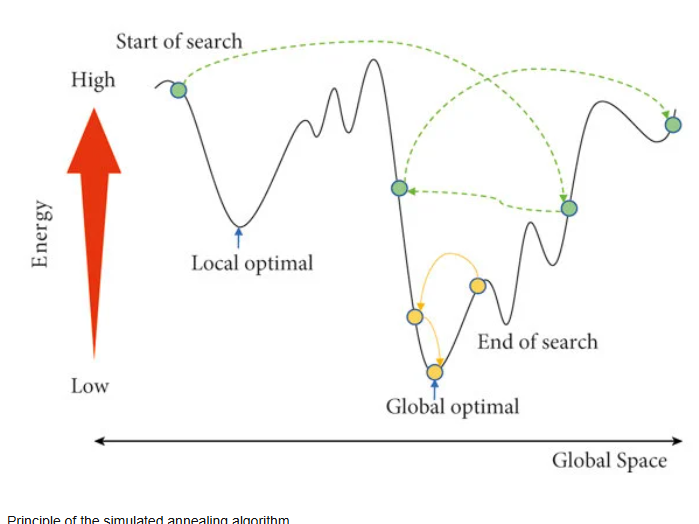

### Representación del espacio de soluciones

La solución se representa como una planificación de tomas por días, que se modifica mediante operadores de vecindario (intercambios o reinserciones).

### Función objetivo

Se minimiza el número total de actor-días. A diferencia de otros métodos, el recocido simulado permite aceptar soluciones peores de forma probabilística en función de la temperatura.

### Implementación de las restricciones

Las restricciones se garantizan en todo momento, ya que los movimientos aplicados generan únicamente soluciones válidas, preservando la estructura de la planificación.

In [14]:
def recocido_simulado(plan_inicial, P, T0=10, alpha=0.995, max_iter=5000):

    plan_actual = [dia.copy() for dia in plan_inicial]
    coste_actual = coste_total(plan_actual, P)

    mejor_plan = [dia.copy() for dia in plan_actual]
    mejor_coste = coste_actual

    T = T0

    for i in range(max_iter):
        vecino = generar_vecino(plan_actual)
        coste_vecino = coste_total(vecino, P)

        delta = coste_vecino - coste_actual

        if delta < 0 or random.random() < math.exp(-delta / T):
            plan_actual = vecino
            coste_actual = coste_vecino

            if coste_actual < mejor_coste:
                mejor_plan = [dia.copy() for dia in plan_actual]
                mejor_coste = coste_actual
                print(f"Iter {i}: nuevo mejor coste = {mejor_coste}")

        T *= alpha

    return mejor_plan, mejor_coste

In [15]:
plan_sa, coste_sa = recocido_simulado(plan_mabl, P, T0=10, alpha=0.995, max_iter=8000)

print("Coste recocido simulado:", coste_sa)
display(mostrar_planificacion(plan_sa, P))

Iter 1838: nuevo mejor coste = 27
Coste recocido simulado: 27


,Día,Tomas,Nº tomas,Actores presentes
0,1,"[28, 25, 9, 22, 12, 16]",6,6
1,2,"[17, 19, 14, 23, 24, 18]",6,3
2,3,"[10, 11, 8, 26, 21, 29]",6,7
3,4,"[4, 7, 3, 13, 5, 15]",6,6
4,5,"[20, 2, 6, 27, 30, 1]",6,5


## Análisis del resultado y valoración del enfoque (recocido simulado)

### Verificación de la solución

La planificación obtenida distribuye las 30 tomas en 5 días, cumpliendo todas las restricciones del problema:

- Todas las tomas están asignadas exactamente una vez  
- No hay duplicados ni omisiones  
- Ningún día supera el límite de 6 tomas  
- El cálculo de actores por día es coherente con las tomas asignadas  

Por tanto, la solución es factible y válida.


### Valor de la función objetivo

El recocido simulado obtiene un coste total de **27 actor-días**, igualando el mejor resultado obtenido previamente mediante multiarranque y búsqueda local.

Este valor representa una planificación altamente eficiente en la agrupación de tomas con actores comunes.


### Calidad de la solución

El recocido simulado se aplica a partir de una solución ya optimizada, introduciendo un mecanismo probabilístico que permite aceptar soluciones peores de forma controlada.

Esto permite explorar regiones del espacio de soluciones que no serían accesibles mediante métodos deterministas.

El hecho de no mejorar el resultado previo, pero sí reproducirlo, indica que la solución alcanzada es estable y difícil de superar mediante técnicas heurísticas.


### Coste computacional

La complejidad del recocido simulado viene dada por:

$$
O(\text{iteraciones} \cdot n_{tomas}^2 \cdot n_{actores})
$$

ya que en cada iteración se genera un vecino y se evalúa su coste.

El rendimiento depende de parámetros como la temperatura inicial, la tasa de enfriamiento y el número de iteraciones.


### Adecuación del enfoque

El recocido simulado resulta adecuado porque:

- Permite escapar de óptimos locales  
- Introduce exploración probabilística del espacio de soluciones  
- Es capaz de encontrar soluciones de alta calidad  

En este caso, se utiliza como mecanismo de refinamiento y validación de la solución obtenida previamente.


### Conclusión

El recocido simulado confirma la calidad de la solución obtenida, a **27 actor-días**, mejorando incluso el valor obtenido con multiarranque y búsqueda local.


## **5. Variable Neighborhood Search (VNS)**

Como paso adicional, se aplica el algoritmo VNS con el objetivo de explorar distintas estructuras de vecindario y validar la calidad de la solución obtenida.

A diferencia de la búsqueda local, VNS utiliza múltiples vecindarios, lo que permite diversificar la exploración del espacio de soluciones y evitar el estancamiento en óptimos locales.

En este trabajo, VNS se emplea como técnica de validación sobre la mejor solución encontrada previamente.

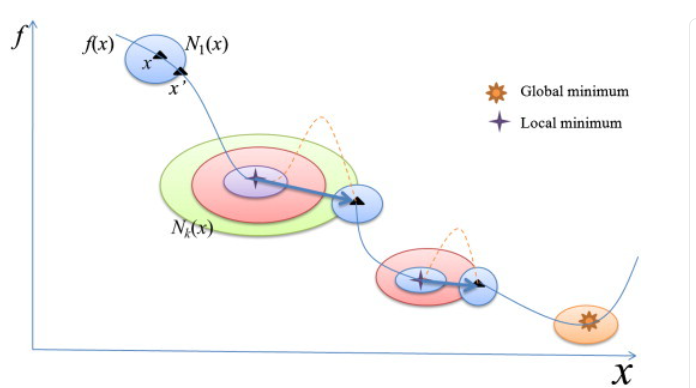

### Representación del espacio de soluciones

La solución se representa como una planificación por días, derivada de una permutación de tomas.

VNS trabaja sobre esta representación generando soluciones vecinas mediante distintos tipos de transformaciones (intercambios, reinserciones o modificaciones de segmentos), lo que permite explorar diferentes estructuras del espacio de soluciones.

### Función objetivo

Se minimiza el número total de actor-días, evaluando cada solución mediante la función `coste_total`.

El algoritmo compara las soluciones generadas en distintos vecindarios y selecciona aquellas que mejoran el coste.

### Implementación de las restricciones

Las restricciones se mantienen en todas las soluciones generadas, ya que los movimientos definidos en los distintos vecindarios preservan:

- la unicidad de las tomas  
- el número máximo de tomas por día  
- la validez de la planificación  

Esto garantiza que todas las soluciones exploradas sean factibles.

### Estrategia de búsqueda

VNS combina dos mecanismos fundamentales:

- **Diversificación**: mediante la exploración de distintos vecindarios (shaking), que permiten saltar a regiones diferentes del espacio de soluciones  
- **Intensificación**: mediante la aplicación de búsqueda local sobre cada solución generada  

El algoritmo cambia de vecindario cuando no se encuentran mejoras, lo que permite evitar el estancamiento en óptimos locales y ampliar la exploración del espacio de soluciones.

In [16]:
def plan_a_permutacion(plan):
    return [t for dia in plan for t in dia]

In [17]:
def generar_vecino_vns(perm, k):
    nueva = perm.copy()
    n = len(nueva)

    if k == 1:
        # Swap de dos tomas
        i, j = random.sample(range(n), 2)
        nueva[i], nueva[j] = nueva[j], nueva[i]

    elif k == 2:
        # Reinserción
        i, j = random.sample(range(n), 2)
        toma = nueva.pop(i)
        nueva.insert(j, toma)

    elif k == 3:
        # Inversión de un segmento
        i, j = sorted(random.sample(range(n), 2))
        nueva[i:j+1] = reversed(nueva[i:j+1])

    return nueva

In [18]:
def busqueda_local_desde_perm(perm_inicial, P, max_iter=1000):
    perm_actual = perm_inicial.copy()
    plan_actual = permutacion_a_planificacion(perm_actual, n_dias, max_tomas_dia)
    coste_actual = coste_total(plan_actual, P)

    mejor_perm = perm_actual.copy()
    mejor_coste = coste_actual

    for _ in range(max_iter):
        vecino = generar_vecino_vns(perm_actual, k=1)  # local simple con swap
        plan_vecino = permutacion_a_planificacion(vecino, n_dias, max_tomas_dia)
        coste_vecino = coste_total(plan_vecino, P)

        if coste_vecino < coste_actual:
            perm_actual = vecino
            coste_actual = coste_vecino

            if coste_vecino < mejor_coste:
                mejor_perm = vecino.copy()
                mejor_coste = coste_vecino

    return mejor_perm, mejor_coste

In [19]:
def VNS(plan_inicial, P, k_max=3, iteraciones=200):
    perm_mejor = plan_a_permutacion(plan_inicial)
    plan_mejor = permutacion_a_planificacion(perm_mejor, n_dias, max_tomas_dia)
    coste_mejor = coste_total(plan_mejor, P)

    historial = [coste_mejor]

    for it in range(iteraciones):
        k = 1

        while k <= k_max:
            # 1. Agitación (shaking)
            perm_vecina = generar_vecino_vns(perm_mejor, k)

            # 2. Búsqueda local desde esa solución
            perm_local, coste_local = busqueda_local_desde_perm(perm_vecina, P, max_iter=500)

            # 3. Decisión
            if coste_local < coste_mejor:
                perm_mejor = perm_local.copy()
                plan_mejor = permutacion_a_planificacion(perm_mejor, n_dias, max_tomas_dia)
                coste_mejor = coste_local
                historial.append(coste_mejor)
                print(f"Iteración {it}, vecindario {k}: nuevo mejor coste = {coste_mejor}")
                k = 1
            else:
                k += 1

    return plan_mejor, coste_mejor, historial

In [20]:
plan_vns, coste_vns, hist_vns = VNS(plan_sa, P, k_max=3, iteraciones=300)

print("Coste VNS:", coste_vns)
display(mostrar_planificacion(plan_vns, P))

Coste VNS: 27


,Día,Tomas,Nº tomas,Actores presentes
0,1,"[28, 25, 9, 22, 12, 16]",6,6
1,2,"[17, 19, 14, 23, 24, 18]",6,3
2,3,"[10, 11, 8, 26, 21, 29]",6,7
3,4,"[4, 7, 3, 13, 5, 15]",6,6
4,5,"[20, 2, 6, 27, 30, 1]",6,5


## Análisis del resultado y valoración del enfoque (VNS)

### Verificación de la solución

La planificación obtenida cumple todas las restricciones del problema:

- Todas las tomas están asignadas exactamente una vez  
- No hay duplicados ni omisiones  
- Ningún día supera el límite de 6 tomas  
- El número de actores por día es coherente con las tomas asignadas  

Por tanto, la solución es factible y válida.


### Valor de la función objetivo

El algoritmo VNS obtiene un coste total de **27 actor-días**, igualando los mejores resultados obtenidos mediante recocido simulado y multiarranque con búsqueda local.

Este valor representa una planificación altamente eficiente en la agrupación de tomas.


### Calidad de la solución

VNS introduce distintos vecindarios para diversificar la búsqueda y evitar el estancamiento en óptimos locales.

En este caso, no se observa una mejora respecto a los métodos anteriores, pero sí una **reproducción consistente del mejor resultado**, lo que indica una alta estabilidad de la solución.


### Coste computacional

La complejidad de VNS es superior a la de los métodos anteriores, ya que combina:

- exploración de múltiples vecindarios  
- generación de soluciones vecinas  
- aplicación de búsqueda local  

lo que puede expresarse como:

$$
O(\text{iteraciones} \cdot k_{max} \cdot n_{tomas}^2 \cdot n_{actores})
$$

Esto implica un mayor coste computacional respecto a otras técnicas.


### Adecuación del enfoque

VNS es adecuado para:

- explorar distintas estructuras de vecindario  
- evitar el estancamiento en óptimos locales  
- validar la calidad de las soluciones obtenidas  

En este trabajo, se utiliza como técnica de validación adicional.


### Conclusión

El algoritmo VNS confirma la calidad de la solución obtenida, alcanzando el mismo valor mínimo de 27 actor-días.

El hecho de que distintas metaheurísticas converjan al mismo resultado refuerza la hipótesis de que la solución encontrada podría estar próxima al óptimo global del problema.

# Comparativa de métodos

| Método | Tipo | Coste obtenido | Complejidad | Observaciones |
|--------|------|----------------|-------------|---------------|
| Voraz | Heurística constructiva | 37 | $O(n)$ | Muy rápida, pero decisiones miopes |
| Voraz + multiarranque | Heurística constructiva mejorada | 35 | $O(k\,n)$ | Reduce dependencia del orden inicial |
| Búsqueda local | Heurística de mejora | 34 | $O(n^2)$ | Mejora significativa, pero puede estancarse |
| Multiarranque + BL | Heurística híbrida | 28 | $O(k\,n^2)$ | Mejora el equilibrio calidad-coste |
| Recocido simulado | Metaheurística | **27** | $O(n^2)$ | Permite escapar de óptimos locales |
| VNS | Metaheurística | 27 | $O(n^3)$ | Valida estabilidad, mayor coste |

Las complejidades mostradas son una simplificación orientada a la comparación global entre métodos. En la práctica, algunos algoritmos dependen también del número de iteraciones, del número de arranques o del número de vecindarios considerados.

# **Conclusión final**

A lo largo de este trabajo se ha abordado el problema de planificación de sesiones de doblaje mediante un enfoque heurístico y metaheurístico, analizando de forma progresiva distintas técnicas de optimización.

Los resultados muestran que:

- Las heurísticas constructivas permiten obtener soluciones rápidas, aunque de calidad limitada.
- La búsqueda local mejora significativamente la solución inicial al introducir refinamiento iterativo.
- El uso de multiarranque incrementa la robustez del proceso, reduciendo la dependencia de la solución inicial.
- Las metaheurísticas, como el recocido simulado, permiten explorar de forma más amplia el espacio de soluciones, alcanzando resultados de alta calidad.
- VNS confirma la estabilidad de la solución obtenida, sin aportar mejoras adicionales.

El hecho de que múltiples enfoques distintos (recocido simulado y VNS) converjan al mismo valor de **27 actor-días** sugiere que la solución encontrada está muy próxima al óptimo global del problema.

Desde el punto de vista del coste computacional, se observa un compromiso claro entre simplicidad y calidad de la solución. Mientras que los métodos más simples presentan un coste bajo pero resultados limitados, las técnicas más avanzadas permiten obtener soluciones significativamente mejores a costa de un mayor esfuerzo computacional.

En conclusión, el **recocido simulado** se presenta como el método más eficaz probado, ofreciendo la mejor calidad de solución al coste computacional más asumible.

## Referencias

Reyero Díez, R. (s.f.). *Algoritmos de optimización*. Universidad Internacional de Valencia.

Aarts, E., & Korst, J. (1988). *Simulated annealing and Boltzmann machines*. John Wiley & Sons.

Hansen, P., & Mladenović, N. (2001). Variable neighborhood search: Principles and applications. *European Journal of Operational Research*, 130(3), 449–467. https://dl.acm.org/doi/10.1145/937503.937505

Talbi, E.-G. (2009). *Metaheuristics: From design to implementation*. Wiley.

Principle of the simulated annealing algorithm [Figura]. (s.f.). ResearchGate. https://www.researchgate.net/figure/Principle-of-the-simulated-annealing-algorithm_fig5_360434054

**Herramientas utilizadas**

- Python (NumPy, Pandas) y Google Colab para la implementación.
- Asistencia de un modelo de lenguaje (ChatGPT, OpenAI) para apoyo en la redacción y revisión del trabajo.